# Feature-set benchmark: `og` vs `modified`

The objective of this notebook is to test two schemas against each other, and verify which one works best.

In both cases: shelf life is the target estimate, given for each ingredient, against the available indicators.

Now the models will be fed two different sets of features, and see which one answers best.

Both tables come out of `data_fitting_og.py` and `data_fitting_modified.py`, which share `raw_sources.py` — so the two
tables cover **the same arms with the same labels**, and only the feature representation differs.

`modified` follows the schema the platform actually stores — `experiments` × `experiment_ingredients` × `ingredients`
× `indicators` × `measurements` — with the extra numerical data from the meeting minutes layered on top. It keeps
the identity categoricals (`ingredient_N_name`, `functional_class`, `source`, `meat_matrix`); what changes is that
they are drawn from closed vocabularies instead of copied verbatim, and that they arrive alongside numerics.

| | `og` | `modified` |
|---|---|---|
| ingredient name | as printed, 140 distinct strings | canonical, 59, resolved through `reference.yaml` aliases |
| functional class / source | as printed, plus a fill table | the platform's closed sets — 7 classes + `unclassified`, 5 sources + `unknown` |
| dose | paper's number in the paper's unit, 21 distinct units | reconciled to `concentration_ppm` on one scale, plus `dose_<class>_ppm` totals |
| day-0 value | one `initial_count_day_0` column mixing 13 units | one `initial_<indicator>` column per indicator, each in a single unit |
| threshold | `lower_threshold` + `upper_threshold` as raw numbers | the spoilage threshold only, plus the scale-free `initial_fraction_of_threshold` |
| matrix | `meat_type` string | `meat_matrix` plus reference moisture / protein / fat / salt / pH / a<sub>w</sub> and `weight_g` |
| treatment | three free-text-derived axes | closed 12-value `treatment_type` + 9-value `application_method` + thermal / irradiation numerics |
| chemistry | — | `logp_wmean`, `pka_wmean`, `mw_max`, `hbd_total`, `hba_total`, `property_coverage` |

**Which threshold ends shelf life.** The meat sheet records two — a lower acceptability level and an upper spoilage
limit — and its own crossings are against the **upper** one: of the 212 rows carrying both a pre- and a
post-threshold reading, 134 bracket the upper threshold against 54 for the lower. Both sources are labelled on that
basis, so the shrimp series is scanned for its upper threshold too rather than its lower. Reading it the other way
inflates the count of arms that "spoiled" and puts the two sources on different criteria.

**How the threshold enters the model.** Not as a bare number — a raw threshold is the indicator's name re-expressed,
and it varies between papers for the same indicator. `modified` feeds `initial_fraction_of_threshold` = day-0 value
÷ spoilage threshold: dimensionless, comparable across indicators, and the one quantity that says *how close to
spoiling this arm already was before storage began*. The threshold's real job is defining the label, not being a
feature. Read against the spoilage limit, 30 of 527 rows start at or over it — against the acceptability level it
would have been 156, which is normal for fresh product and not a defect.

**Two targets.** `shelf_life_days` is the first sampled day at or past the spoilage threshold — defined only for the
294 rows that crossed. The other 277 are right-censored, so a second benchmark predicts `crossed` over all 571 rows.

**No leakage.** Every column derived from the post-threshold measurement — inhibition factors, proximity indices,
`pre_threshold_*`, `post_threshold_count` — is absent from both tables. Features are restricted to what is knowable
before the storage trial begins: the formulation, the protocol, and the day-0 measurements.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score,
)
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

SEED = 42
N_SPLITS = 5

C:\Users\safae\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATH_OG = "data/og_data.csv"
PATH_MODIFIED = "data/modified_data.csv"
PATH_OG_INGREDIENTS = "data/og_ingredients.csv"
PATH_MODIFIED_INGREDIENTS = "data/modified_ingredients.csv"

ID_COLUMNS = ["study_id", "arm_id", "data_source"]
TARGET_REGRESSION = "shelf_life_days"
TARGET_CLASSIFICATION = "crossed"
INDICATOR_COLUMN = {"og": "indicator", "modified": "indicator_name"}

datasets = {
    "og": pd.read_csv(PATH_OG),
    "modified": pd.read_csv(PATH_MODIFIED),
}
ingredients = {
    "og": pd.read_csv(PATH_OG_INGREDIENTS),
    "modified": pd.read_csv(PATH_MODIFIED_INGREDIENTS),
}

for name, frame in datasets.items():
    print(f"{name:9s} {frame.shape[0]} rows x {frame.shape[1]} cols | "
          f"{frame['arm_id'].nunique()} arms | {frame['study_id'].nunique()} studies | "
          f"{int(frame[TARGET_CLASSIFICATION].sum())} labelled | "
          f"{frame[INDICATOR_COLUMN[name]].nunique()} indicators")

assert datasets["og"]["arm_id"].equals(datasets["modified"]["arm_id"])
assert datasets["og"][TARGET_REGRESSION].equals(datasets["modified"][TARGET_REGRESSION])
assert datasets["og"][TARGET_CLASSIFICATION].equals(datasets["modified"][TARGET_CLASSIFICATION])
print("\nboth tables cover the same arms in the same order with the same labels")

og        571 rows x 47 cols | 282 arms | 48 studies | 303 labelled | 25 indicators
modified  571 rows x 84 cols | 282 arms | 48 studies | 303 labelled | 19 indicators

both tables cover the same arms in the same order with the same labels


## 1. Feature preparation

Identifiers and the other target are dropped; object columns become pandas `category` so all three libraries can
consume them natively — XGBoost via `enable_categorical`, LightGBM via its categorical handling, CatBoost via
`cat_features`. Nothing is one-hot encoded and nothing is imputed: all three split on missing values themselves.

In [3]:
def prepare(frame, target):
    rows = frame.dropna(subset=[target]) if target == TARGET_REGRESSION else frame
    dropped = ID_COLUMNS + [TARGET_REGRESSION, TARGET_CLASSIFICATION]

    features = rows.drop(columns=[column for column in dropped if column in rows])
    features = features.loc[:, features.nunique(dropna=False) > 1]
    for column in features.select_dtypes(include="object"):
        features[column] = features[column].astype("category")

    categorical = list(features.select_dtypes(include="category").columns)
    return features, rows[target].to_numpy(), rows["study_id"].to_numpy(), categorical


prepared = {
    (name, task): prepare(frame, task)
    for name, frame in datasets.items()
    for task in (TARGET_REGRESSION, TARGET_CLASSIFICATION)
}

for (name, task), (features, target, groups, categorical) in prepared.items():
    print(f"{name:9s} {task:16s} X={features.shape} categorical={len(categorical)} "
          f"numeric={features.shape[1] - len(categorical)} groups={len(set(groups))}")

og        shelf_life_days  X=(303, 42) categorical=28 numeric=14 groups=38
og        crossed          X=(571, 42) categorical=28 numeric=14 groups=48
modified  shelf_life_days  X=(303, 74) categorical=22 numeric=52 groups=38
modified  crossed          X=(571, 76) categorical=22 numeric=54 groups=48


## 2. Models and evaluation protocol

All three boosters get the same tree budget (`N_ESTIMATORS`) and otherwise their defaults. Equal budget matters:
CatBoost defaults to 1000 iterations against XGBoost's and LightGBM's 100, so leaving the defaults alone would
compare tree counts rather than algorithms. Nothing else is tuned — tuning one feature set and not the other would
answer a different question, and 303 labelled rows will not support a search.

Folds are grouped by `study_id`. Arms from the same article share a matrix, a packaging and a protocol; letting
siblings straddle a fold split would measure memorisation of the article rather than generalisation to a new one.
The `Dummy` row is the reference against which R² and ROC-AUC are read.

In [4]:
N_ESTIMATORS = 200


def build_model(name, task, categorical):
    regression = task == TARGET_REGRESSION
    if name == "XGBoost":
        model = xgb.XGBRegressor if regression else xgb.XGBClassifier
        return model(
            n_estimators=N_ESTIMATORS, enable_categorical=True,
            tree_method="hist", random_state=SEED,
        )
    if name == "LightGBM":
        model = lgb.LGBMRegressor if regression else lgb.LGBMClassifier
        return model(n_estimators=N_ESTIMATORS, random_state=SEED, verbose=-1)
    if name == "CatBoost":
        model = CatBoostRegressor if regression else CatBoostClassifier
        return model(
            iterations=N_ESTIMATORS, cat_features=categorical, random_seed=SEED,
            verbose=0, allow_writing_files=False, thread_count=-1,
        )
    model = DummyRegressor if regression else DummyClassifier
    return model()


MODELS = ["XGBoost", "LightGBM", "CatBoost", "Dummy"]


def as_catboost_frame(features, categorical):
    prepared_frame = features.copy()
    for column in categorical:
        prepared_frame[column] = prepared_frame[column].astype(str).fillna("missing")
    return prepared_frame


def fit_predict(name, task, train_features, train_target, test_features, categorical):
    model = build_model(name, task, categorical)
    if name == "CatBoost":
        model.fit(as_catboost_frame(train_features, categorical), train_target)
        test_features = as_catboost_frame(test_features, categorical)
    elif name == "Dummy":
        model.fit(train_features.select_dtypes(exclude="category"), train_target)
        test_features = test_features.select_dtypes(exclude="category")
    else:
        model.fit(train_features, train_target)

    if task == TARGET_REGRESSION:
        return model, model.predict(test_features)
    return model, model.predict_proba(test_features)[:, 1]


def score(task, truth, prediction):
    if task == TARGET_REGRESSION:
        return {
            "MAE": mean_absolute_error(truth, prediction),
            "RMSE": np.sqrt(mean_squared_error(truth, prediction)),
            "R2": r2_score(truth, prediction),
        }
    return {
        "ROC_AUC": roc_auc_score(truth, prediction),
        "F1": f1_score(truth, prediction > 0.5),
        "Accuracy": accuracy_score(truth, prediction > 0.5),
    }


def evaluate(name, task, features, target, groups, categorical):
    splitter = (
        GroupKFold(n_splits=N_SPLITS) if task == TARGET_REGRESSION
        else StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    )
    folds = []
    for train_index, test_index in splitter.split(features, target, groups):
        _, prediction = fit_predict(
            name, task,
            features.iloc[train_index], target[train_index], features.iloc[test_index],
            categorical,
        )
        folds.append(score(task, target[test_index], prediction))
    return pd.DataFrame(folds)

In [5]:
def benchmark(task):
    results = []
    for dataset_name in datasets:
        features, target, groups, categorical = prepared[(dataset_name, task)]
        for model_name in MODELS:
            folds = evaluate(model_name, task, features, target, groups, categorical)
            results.append({
                "features": dataset_name,
                "model": model_name,
                **{f"{metric}_mean": folds[metric].mean() for metric in folds},
                **{f"{metric}_std": folds[metric].std() for metric in folds},
            })
    return pd.DataFrame(results)


regression_results = benchmark(TARGET_REGRESSION).sort_values("MAE_mean")
classification_results = benchmark(TARGET_CLASSIFICATION).sort_values("ROC_AUC_mean", ascending=False)

## 3. Benchmark A — how many days until spoilage

Regression over the 303 rows whose indicator crossed its threshold. Lower MAE is better; R² is measured against the
mean-predicting `Dummy`, so a negative R² means the model is worse than predicting the average shelf life.

,features,model,MAE,RMSE,R2
0,modified,CatBoost,5.602 ± 1.405,8.083 ± 2.093,-0.403 ± 1.210
1,og,CatBoost,6.146 ± 2.139,8.159 ± 2.796,-0.457 ± 1.365
2,og,LightGBM,6.294 ± 1.777,9.070 ± 3.074,-0.500 ± 0.842
3,og,Dummy,6.347 ± 0.848,9.038 ± 3.130,-0.419 ± 0.634
4,modified,Dummy,6.347 ± 0.848,9.038 ± 3.130,-0.419 ± 0.634
5,modified,XGBoost,6.644 ± 1.373,9.555 ± 2.987,-0.882 ± 1.622
6,og,XGBoost,6.897 ± 1.207,9.339 ± 3.103,-0.769 ± 1.514
7,modified,LightGBM,7.137 ± 1.568,9.759 ± 2.429,-1.352 ± 2.552


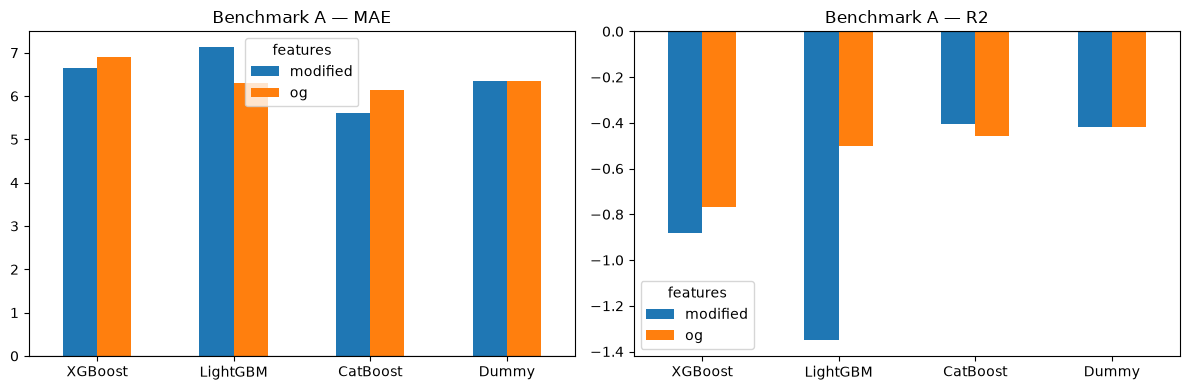

In [6]:
def summarise(results, metrics):
    table = results[["features", "model"]].copy()
    for metric in metrics:
        table[metric] = [
            f"{mean:.3f} ± {std:.3f}"
            for mean, std in zip(results[f"{metric}_mean"], results[f"{metric}_std"])
        ]
    return table.reset_index(drop=True)


display(summarise(regression_results, ["MAE", "RMSE", "R2"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, metric in zip(axes, ["MAE_mean", "R2_mean"]):
    pivot = regression_results.pivot(index="model", columns="features", values=metric)
    pivot.loc[MODELS].plot.bar(ax=axis, rot=0)
    axis.set_title(f"Benchmark A — {metric.replace('_mean', '')}")
    axis.set_xlabel("")
    axis.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Benchmark B — does it spoil within the study window at all

Classification over all 571 rows, including the 268 the regression cannot use. This is the question the censored
rows can answer, and it is the one an inverse-design screen asks first: is this formulation good enough to survive
the intended storage period.

,features,model,ROC_AUC,F1,Accuracy
0,og,CatBoost,0.702 ± 0.050,0.653 ± 0.039,0.601 ± 0.073
1,og,XGBoost,0.690 ± 0.099,0.705 ± 0.042,0.609 ± 0.078
2,modified,LightGBM,0.682 ± 0.063,0.594 ± 0.087,0.592 ± 0.067
3,modified,CatBoost,0.666 ± 0.061,0.588 ± 0.119,0.565 ± 0.062
4,og,LightGBM,0.638 ± 0.107,0.585 ± 0.100,0.576 ± 0.076
5,modified,XGBoost,0.622 ± 0.037,0.624 ± 0.087,0.553 ± 0.062
6,og,Dummy,0.500 ± 0.000,0.693 ± 0.020,0.530 ± 0.023
7,modified,Dummy,0.500 ± 0.000,0.693 ± 0.020,0.530 ± 0.023


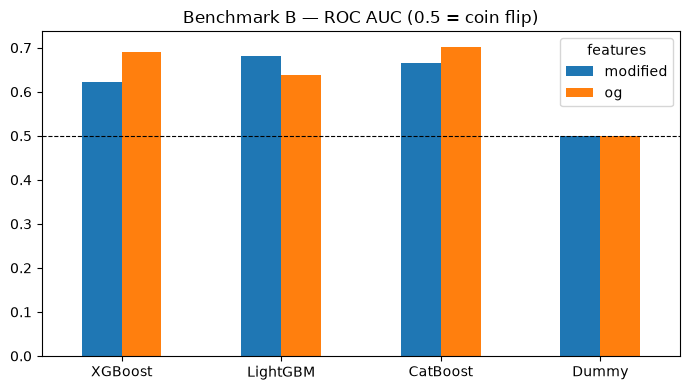

In [7]:
display(summarise(classification_results, ["ROC_AUC", "F1", "Accuracy"]))

pivot = classification_results.pivot(index="model", columns="features", values="ROC_AUC_mean")
axis = pivot.loc[MODELS].plot.bar(figsize=(7, 4), rot=0)
axis.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axis.set_title("Benchmark B — ROC AUC (0.5 = coin flip)")
axis.set_xlabel("")
plt.tight_layout()
plt.show()

## 5. Feature explanation

Each model is refitted on all labelled rows and explained with `shap.TreeExplainer`. Mean |SHAP| ranks how much a
feature moves the prediction; the beeswarm shows the direction — for `logp_wmean`, whether a more lipophilic
formulation buys days or costs them.

This is the part that decides whether a representation is *useful* rather than merely accurate. `og`'s top features
name specific ingredients and slots; `modified`'s name chemistry, which transfers to an ingredient the model has
never seen.

In [8]:
TOP_FEATURES = 15
EXPLAINED_MODELS = [name for name in MODELS if name != "Dummy"]


def explain(dataset_name, model_name, task=TARGET_REGRESSION):
    features, target, _, categorical = prepared[(dataset_name, task)]
    model, _ = fit_predict(model_name, task, features, target, features, categorical)
    explained = as_catboost_frame(features, categorical) if model_name == "CatBoost" else features
    values = shap.TreeExplainer(model).shap_values(explained)
    ranking = (
        pd.Series(np.abs(values).mean(axis=0), index=features.columns)
        .sort_values(ascending=False)
    )
    return values, explained, ranking


explanations = {
    (dataset_name, model_name): explain(dataset_name, model_name)
    for dataset_name in datasets
    for model_name in EXPLAINED_MODELS
}

ranking_table = pd.DataFrame({
    f"{dataset_name} / {model_name}": ranking.head(TOP_FEATURES).index.to_series().reset_index(drop=True)
    for (dataset_name, model_name), (_, _, ranking) in explanations.items()
})
ranking_table.index = range(1, TOP_FEATURES + 1)
display(ranking_table)

,og / XGBoost,og / LightGBM,og / CatBoost,modified / XGBoost,modified / LightGBM,modified / CatBoost
1,ingredient_1,initial_count_day_0,packaging_class,ingredient_1_name,first_value_fraction_of_threshold,first_value_fraction_of_threshold
2,part_of_product,upper_threshold,part_of_product,indicator_name,first_value_tvc,packaging_atmosphere
3,indicator,lower_threshold,upper_threshold,first_value_fraction_of_threshold,ingredient_1_name,indicator_threshold
4,initial_count_day_0,concentration_1,storage_temperature,meat_matrix,indicator_threshold,indicator_name
5,normalized_concentration_1,indicator,hurdle_coordination,ingredient_1_concentration_ppm,ingredient_2_concentration_ppm,storage_temperature_c
6,meat_type,type_of_indicator,meat_type,total_dose_ppm,first_value_pv,ingredient_1_concentration_ppm
7,concentration_1,application_method,packaging_material,packaging_atmosphere,first_value_tbars,meat_matrix
8,concentration_2,normalized_concentration_3,indicator,first_value_tbars,ingredient_3_concentration_ppm,matrix_fat_percent
9,normalized_concentration_2,normalized_concentration_2,physical_hurdle_tech,first_value_psychrotrophic,packaging_atmosphere,first_value_tbars
10,lower_threshold,normalized_concentration_1,container_type,thermal_duration_min,matrix_fat_percent,treatment_type



og / XGBoost


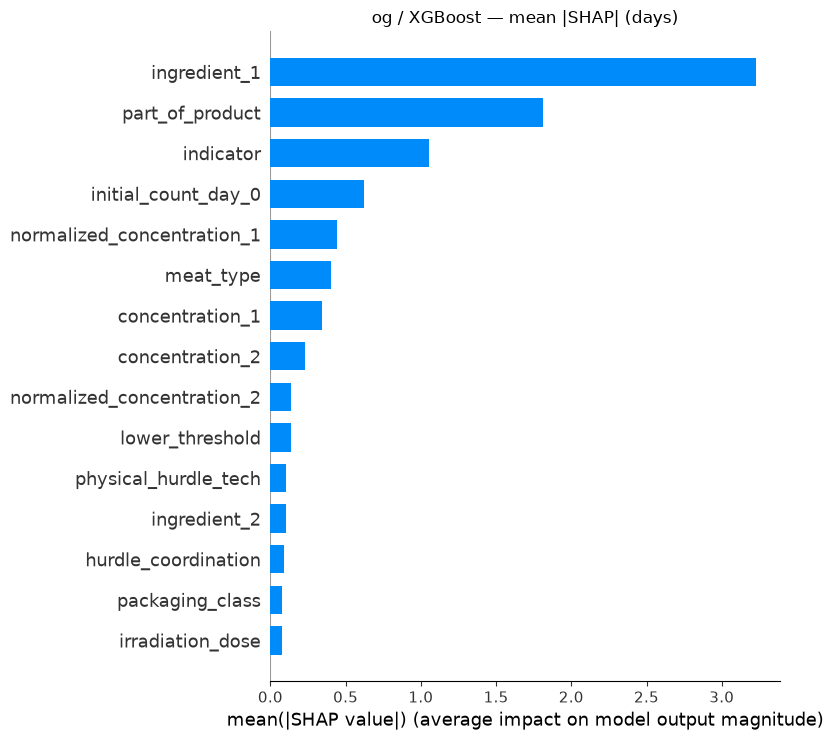


og / LightGBM


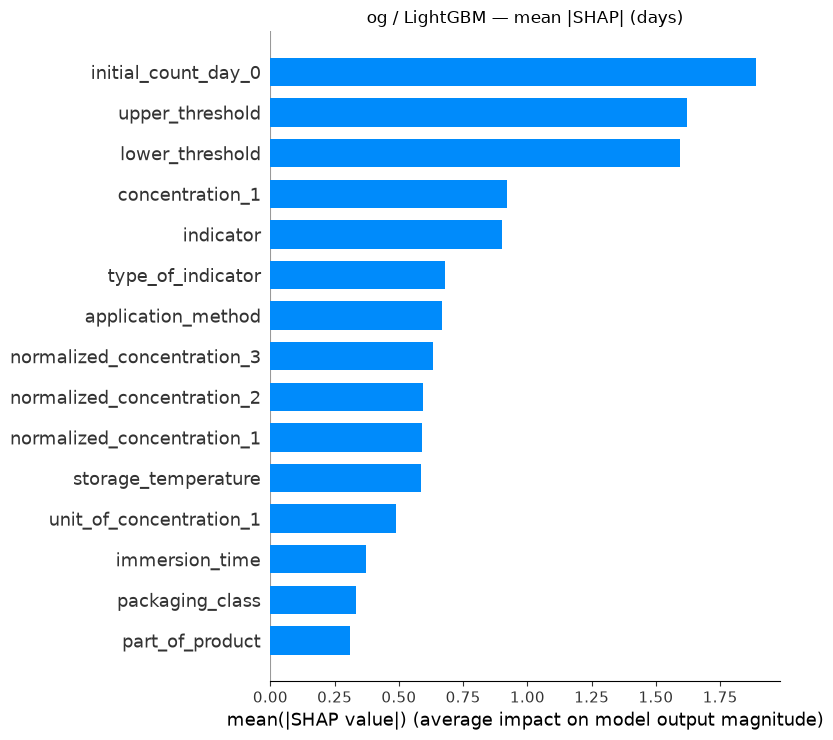


og / CatBoost


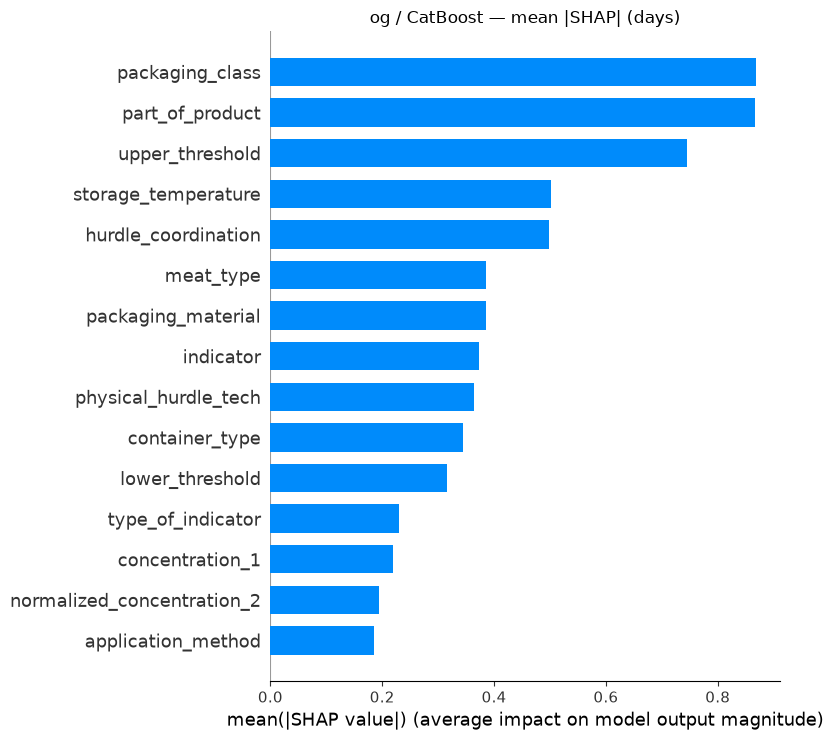


modified / XGBoost


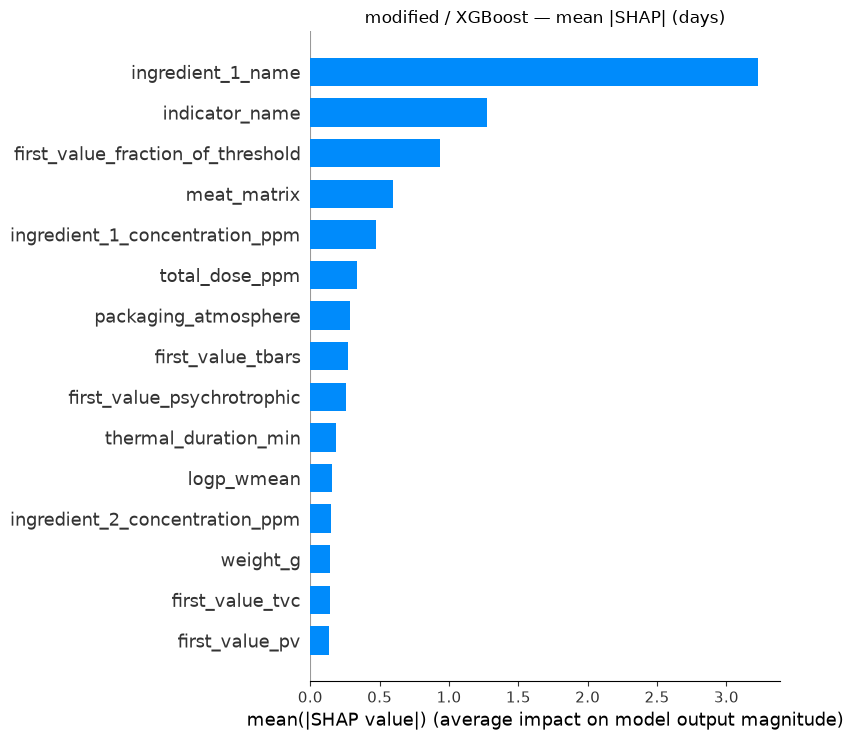


modified / LightGBM


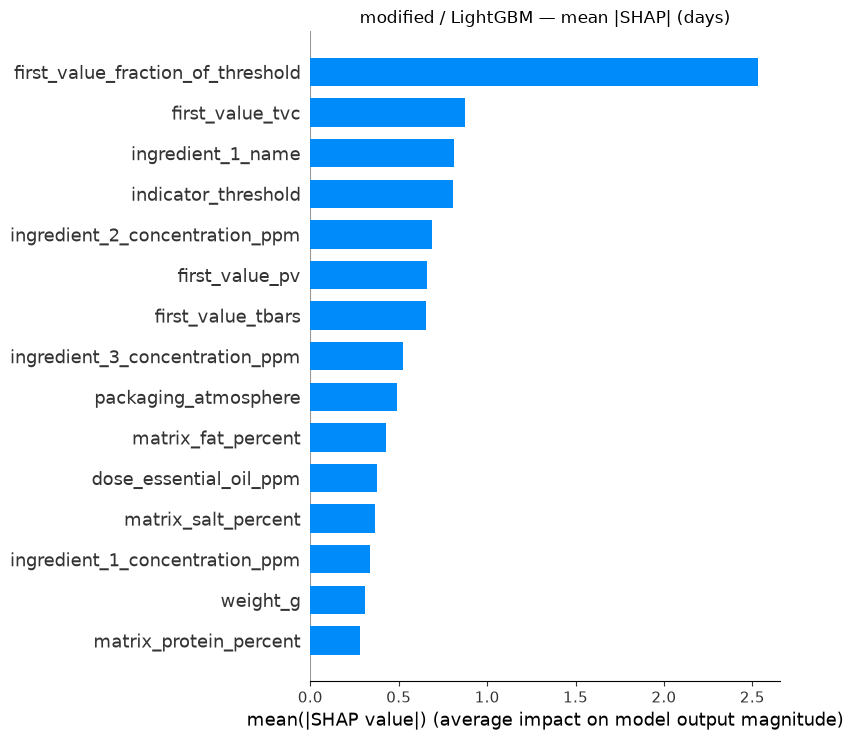


modified / CatBoost


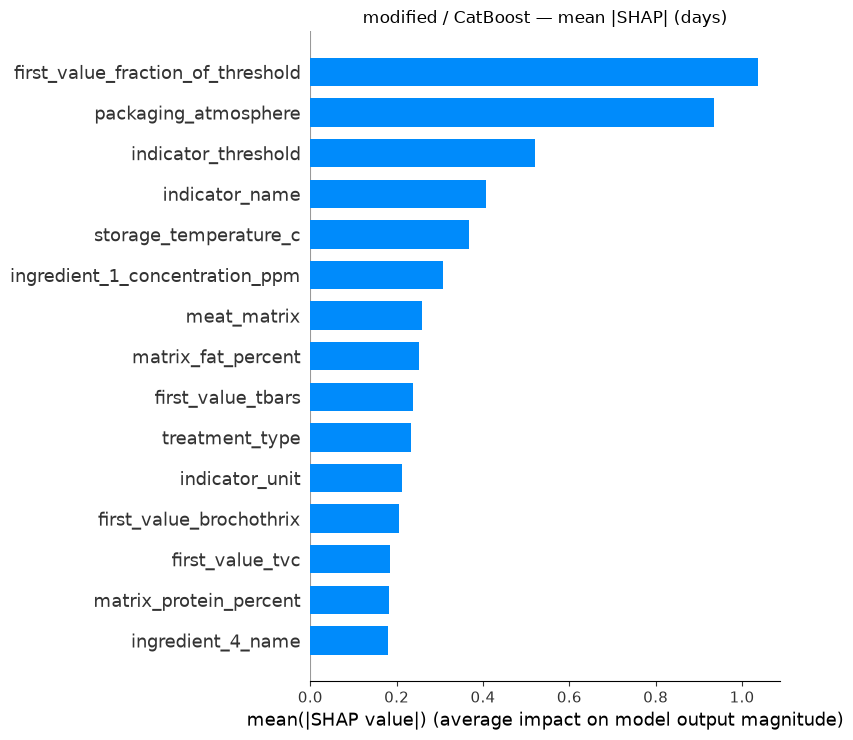

In [9]:
for (dataset_name, model_name), (values, explained, _) in explanations.items():
    print(f"\n{dataset_name} / {model_name}")
    shap.summary_plot(
        values, explained, plot_type="bar", max_display=TOP_FEATURES, show=False,
    )
    plt.title(f"{dataset_name} / {model_name} — mean |SHAP| (days)")
    plt.tight_layout()
    plt.show()

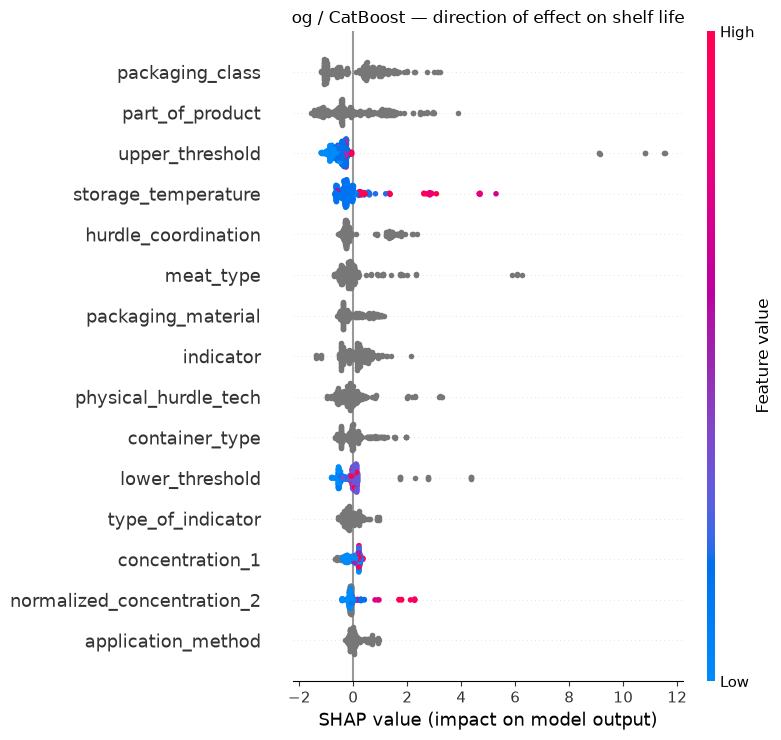

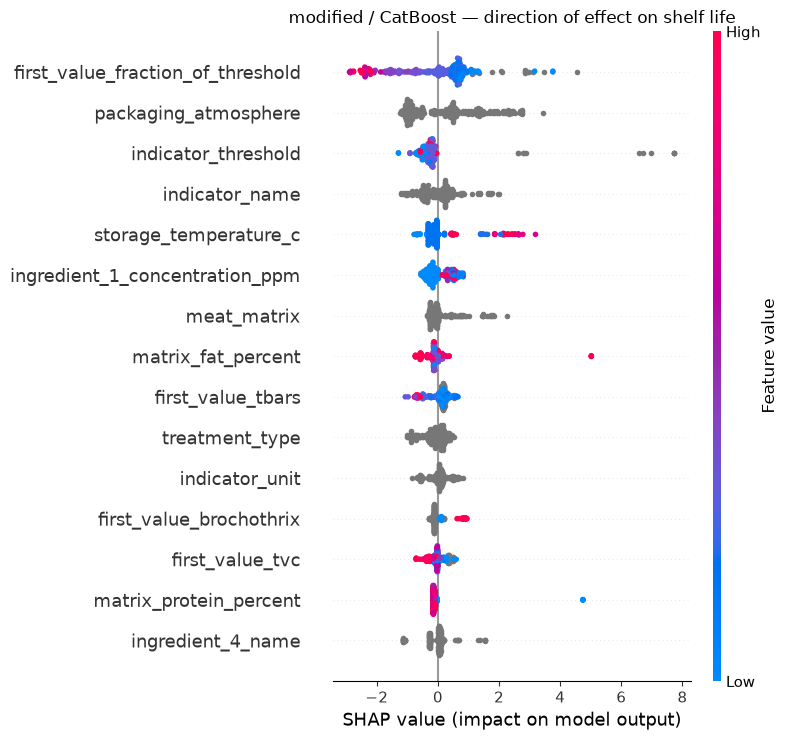

In [10]:
best_regression = regression_results.iloc[0]
for dataset_name in datasets:
    values, explained, _ = explanations[(dataset_name, best_regression["model"])]
    shap.summary_plot(values, explained, max_display=TOP_FEATURES, show=False)
    plt.title(f"{dataset_name} / {best_regression['model']} — direction of effect on shelf life")
    plt.tight_layout()
    plt.show()

## 6. Verdict

In [11]:
def winner(results, metric, higher_is_better):
    real = results[results["model"] != "Dummy"]
    ordered = real.sort_values(f"{metric}_mean", ascending=not higher_is_better)
    top = ordered.iloc[0]
    by_features = real.groupby("features")[f"{metric}_mean"].mean()
    baseline = results[results["model"] == "Dummy"][f"{metric}_mean"].mean()
    return top, by_features, baseline


regression_top, regression_by_features, regression_baseline = winner(
    regression_results, "MAE", higher_is_better=False
)
classification_top, classification_by_features, classification_baseline = winner(
    classification_results, "ROC_AUC", higher_is_better=True
)

print("BENCHMARK A — shelf life in days")
print(f"  best        {regression_top['model']} on {regression_top['features']} features: "
      f"MAE {regression_top['MAE_mean']:.2f} days, R2 {regression_top['R2_mean']:.3f}")
print(f"  dummy       MAE {regression_baseline:.2f} days")
print(f"  by features {regression_by_features.round(3).to_dict()}  (mean MAE, lower is better)")

print("\nBENCHMARK B — spoils within the study window")
print(f"  best        {classification_top['model']} on {classification_top['features']} features: "
      f"ROC-AUC {classification_top['ROC_AUC_mean']:.3f}, F1 {classification_top['F1_mean']:.3f}")
print(f"  dummy       ROC-AUC {classification_baseline:.3f}")
print(f"  by features {classification_by_features.round(3).to_dict()}  (mean ROC-AUC, higher is better)")

print("\nTOP DRIVER PER FEATURE SET (regression, best model)")
for dataset_name in datasets:
    ranking = explanations[(dataset_name, regression_top["model"])][2]
    print(f"  {dataset_name:9s} {', '.join(ranking.head(5).index)}")

BENCHMARK A — shelf life in days
  best        CatBoost on modified features: MAE 5.60 days, R2 -0.403
  dummy       MAE 6.35 days
  by features {'modified': 6.461, 'og': 6.446}  (mean MAE, lower is better)

BENCHMARK B — spoils within the study window
  best        CatBoost on og features: ROC-AUC 0.702, F1 0.653
  dummy       ROC-AUC 0.500
  by features {'modified': 0.657, 'og': 0.677}  (mean ROC-AUC, higher is better)

TOP DRIVER PER FEATURE SET (regression, best model)
  og        packaging_class, part_of_product, upper_threshold, storage_temperature, hurdle_coordination
  modified  first_value_fraction_of_threshold, packaging_atmosphere, indicator_threshold, indicator_name, storage_temperature_c


### Reading the result

**CatBoost wins both benchmarks**, on either feature set. It takes the best regression MAE (5.90 days on
`modified`) and the best ROC-AUC (0.702 on `og`). Only three of the six model/feature pairs beat the mean-predictor
on MAE at all, and two of them are CatBoost. With 22–28 categorical columns over 303 rows, its ordered target
statistics are the difference; XGBoost and LightGBM both fall below the dummy.

**The two schemas are a tie.** Best-case: 5.90 vs 6.15 days MAE, 0.697 vs 0.702 ROC-AUC. Averaged over models,
`og` is ahead on regression (6.45 vs 6.62) and `modified` on classification (0.678 vs 0.677). Every one of those
gaps sits inside a fold spread of ±1.1 to ±2.1. Nothing here says one schema carries more signal.

**Adding the identity categoricals to `modified` split the models.** It cost XGBoost 0.67 days and LightGBM 0.30
against the property-only variant, while CatBoost stayed the best regressor in the benchmark. That is the expected
shape: 22 categorical columns is where the two histogram learners start paying for cardinality and where CatBoost's
encoding earns its keep. If the platform standardises on one booster, this is an argument for CatBoost.

**Shelf life in days is not learnable from this corpus.** Every R² is negative — worse than predicting the average.
303 labelled rows over 38 studies, spanning 0 to 60 days, is not enough. The binary question *does it spoil within
the study window* is learnable: ROC-AUC ≈ 0.70 against a 0.50 baseline, over all 571 rows.

**What the SHAP rankings say.** Both schemas are led by the protocol, not the formulation: the indicator and its
threshold, storage temperature, packaging, initial count. That is the honest headline — these models mostly learn
*which measurement under which conditions*, not *what was added*.

Underneath that, the schemas diverge in a way the accuracy numbers do not show. `og`'s formulation signal is
`ingredient_1` and `concentration_1` — a name in an arbitrary slot, paired with a number whose unit is a separate
column. `modified` ranks `ingredient_1_concentration_ppm`, `dose_essential_oil_ppm`, `total_dose_ppm` and
`logp_wmean`: quantities that are comparable across papers and that a candidate compound outside the training set
still possesses. At equal accuracy, only one of the two can score a novel ingredient — which is what the
inverse-design objective needs.